# Task 4 — Algorithmic Trading Strategies


## 0. Imports & Constants

Standard scientific-Python libraries are imported. Key constants are set here once so
every subsequent cell inherits the same values without ambiguity.

| Constant | Value | Academic rationale |
|---|---|---|
| `IS_WINDOW` | 500 days | Long enough for stable covariance and MA estimates; short enough to adapt to structural breaks. Comparable to the 1–2 year IS windows used in the systematic-strategies literature (Moskowitz et al. 2012). |
| `OOS_STEP` | 100 days | Each OOS block covers roughly one calendar quarter. Smaller steps inflate the number of overlapping folds; larger steps reduce granularity. 100 days is a common choice (López de Prado 2018). |
| `RF_ANNUAL` | 0.03 | A 3 % annual rate is used as a conservative risk-free proxy. It is held constant across folds, avoiding look-ahead from using realised short-rate data. |
| `N_BOOT` | 2,000 | At 2,000 resamples, Monte-Carlo error in a p-value near 0.05 is ≈ ±0.005 — sufficient for 2-decimal reporting. |
| `DATA_START` | 1,500 | Excludes per-series multi-day gaps in days 1–1,499 (see Section 1). |


In [252]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.optimize import minimize
from statsmodels.tsa.seasonal import STL
import os, warnings

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})

SERIES        = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']
SENTINEL_DAYS = {2836, 3430, 4118}  # single-day synced gaps within the analysis window
DATA_START    = 1500                # days 1-1499 have per-series multi-day gaps → excluded
RF_ANNUAL     = 0.03        # 3 % annual risk-free rate
TRADING_DAYS  = 365         # calendar-day annualisation (data includes weekends)
IS_WINDOW     = 500         # in-sample calibration window per fold
OOS_STEP      = 100         # OOS block size and walk-forward slide step
N_BOOT        = 2000        # bootstrap resamples for significance testing

os.makedirs('../Output/task4', exist_ok=True)
rf_daily = RF_ANNUAL / TRADING_DAYS   # simple daily rf used for flat-slot earnings
print(f'rf_daily = {rf_daily:.6f}  |  IS={IS_WINDOW} days  |  OOS_STEP={OOS_STEP} days')


rf_daily = 0.000082  |  IS=500 days  |  OOS_STEP=100 days


## 1. Data Loading

### Why we exclude days 1–1,499

Each series has independent multi-day gaps in that period — one asset might be missing
days 200–250 while another is missing days 400–450. After `dropna(how='any')`, only rows
where all seven series simultaneously have data survive, producing a sparse and temporally
misaligned sample. Rolling windows computed on it span unpredictable real-time lengths
and covariance estimates are biased toward the overlapping observation window rather than
the true joint distribution. Excluding these days eliminates the problem at the cost of
six additional rows (the three single-day synced gaps removed by `dropna`).

### Why 70 / 30 development / holdout split

Reserving 70 % for development gives approximately 21 walk-forward folds of 500/100 days.
This is enough to characterise the distribution of fold-level Sharpe ratios (mean,
standard deviation, fraction positive) with reasonable statistical precision. The 30 %
holdout (~1,127 rows, ~11 OoS blocks) is large enough for a meaningful out-of-sample
test while still leaving the majority of data for calibration. The split is chronological
(not random) to respect time-series ordering and prevent look-ahead bias.

> The holdout is loaded here but **not used** until Section 8. All parameter choices and
> strategy comparisons in Sections 3–7 are made on `prices_pseudo` / `lr_pseudo` only.


In [253]:
prices_full = (pd.read_csv('../Data/spiff_data-2.csv', index_col='day')
               .drop(columns=['Unnamed: 0'], errors='ignore'))
prices_full.loc[prices_full.index.isin(SENTINEL_DAYS)] = np.nan

prices_obs   = prices_full.loc[DATA_START:5256, SERIES].copy()
prices_clean = prices_obs.dropna(how='any')
log_returns  = np.log(prices_obs).diff().dropna(how='any')

# 70 / 30 split — first 70% = dev pool, last 30% = true OoS holdout
SPLIT_FRAC     = 0.70
n_clean        = len(prices_clean)
IS_N           = int(n_clean * SPLIT_FRAC)
prices_pseudo  = prices_clean.iloc[:IS_N]
prices_holdout = prices_clean.iloc[IS_N:]
lr_pseudo      = log_returns.loc[log_returns.index.isin(prices_pseudo.index)]
lr_holdout     = log_returns.loc[log_returns.index.isin(prices_holdout.index)]

print(f'Clean prices      : {n_clean} rows  (days {prices_clean.index[0]}–{prices_clean.index[-1]})')
print(f'Dev pool (70%)    : {len(prices_pseudo)} rows')
print(f'True holdout (30%): {len(prices_holdout)} rows  [LOCKED until Section 8]')
print(f'Expected folds    : ~{(len(lr_pseudo) - IS_WINDOW) // OOS_STEP}')


Clean prices      : 3754 rows  (days 1500–5256)
Dev pool (70%)    : 2627 rows
True holdout (30%): 1127 rows  [LOCKED until Section 8]
Expected folds    : ~21


## 2. Performance Framework

All strategies are evaluated using the same set of metrics.

### Sharpe ratio

$$\text{SR} = \frac{\overline{r}\cdot 365 - R_F}{\sigma_r \cdot \sqrt{365}}$$

$\overline{r}$ and $\sigma_r$ are the **daily** mean and standard deviation of strategy returns; $R_F = 0.03$ is the annual risk-free rate. When a strategy is flat (out of the market) it earns `rf_daily = RF / 365` per day.

`backtest_metrics` also reports annualised volatility, Sortino ratio, Calmar ratio, and maximum drawdown. `run_walk_forward` slices the development data into IS/OOS folds and concatenates the OOS blocks — no IS returns are included in performance figures.


In [254]:
def sharpe(daily_rets, ann=TRADING_DAYS, rf=RF_ANNUAL):
    std = daily_rets.std()
    return 0.0 if std < 1e-10 else (daily_rets.mean() * ann - rf) / (std * np.sqrt(ann))

def max_drawdown(daily_rets):
    cum  = (1 + daily_rets).cumprod()
    peak = cum.cummax()
    return ((cum - peak) / peak).min()

def backtest_metrics(daily_rets, label=''):
    r       = daily_rets.dropna()
    ann_ret = r.mean() * TRADING_DAYS
    ann_vol = r.std()  * np.sqrt(TRADING_DAYS)
    sh      = sharpe(r)
    mdd     = max_drawdown(r)
    neg     = r[r < 0]
    dvol    = neg.std() * np.sqrt(TRADING_DAYS) if len(neg) > 1 else np.nan
    sortino = ann_ret / dvol if dvol and dvol > 0 else np.nan
    calmar  = ann_ret / abs(mdd) if mdd < 0 else np.nan
    if label:
        print(f'{label:<32s}  Return={ann_ret:+.2%}  Vol={ann_vol:.2%}  '
              f'Sharpe={sh:.3f}  Sortino={sortino:.3f}  MaxDD={mdd:.2%}')
    return {'Strategy': label, 'Ann. Return': ann_ret, 'Ann. Vol': ann_vol,
            'Sharpe': sh, 'Sortino': sortino, 'Calmar': calmar, 'Max Drawdown': mdd}

def _active_cols(df):
    """Return columns with at least one non-zero value (i.e. capital was deployed)."""
    return [c for c in df.columns if df[c].ne(0).any()]

def run_walk_forward(fold_fn, ret_df, prices_df):
    """
    fold_fn(ret_is, ret_oos, prices_w) -> pd.DataFrame with columns=SERIES.
    Returns (oos_df, fold_sharpes) where fold_sharpes are portfolio-level per fold,
    normalised by the number of assets the strategy actually trades.
    """
    n = len(ret_df)
    oos_chunks, fold_sharpes = [], []
    pos = IS_WINDOW
    while pos + OOS_STEP <= n:
        ret_is   = ret_df.iloc[0 : pos]
        ret_oos  = ret_df.iloc[pos : pos + OOS_STEP]
        prices_w = prices_df.loc[ret_is.index[0] : ret_oos.index[-1]]
        oos      = fold_fn(ret_is, ret_oos, prices_w)
        oos_chunks.append(oos)
        active = _active_cols(oos)
        fold_sharpes.append(sharpe(oos[active].mean(axis=1)))
        pos += OOS_STEP
    return pd.concat(oos_chunks), fold_sharpes

def fold_stats(fold_sharpes, label=''):
    arr = np.array(fold_sharpes)
    pct = np.mean(arr > 0) * 100
    if label:
        print(f'{label:<30s}  mean={arr.mean():.3f}  std={arr.std():.3f}  '
              f'min={arr.min():.3f}  max={arr.max():.3f}  pos={pct:.0f}%')
    return {'Strategy': label, 'Mean Fold SR': arr.mean(), 'Std Fold SR': arr.std(),
            'Min': arr.min(), 'Max': arr.max(), '% Pos Folds': pct}


## 3. Strategy Definitions

Six strategies are evaluated in the main walk-forward (Sections 4–5). They span two
distinct return-generating hypotheses:

- **Passive benchmark** — Buy & Hold (3.1): no market-timing; establishes the baseline
  cost of doing nothing beyond diversification.
- **Trend / momentum** — MA Crossover (3.2): exploits positive autocorrelation in
  price series identified in Task 1. Belongs to the class of *time-series momentum* rules
  with a long literature (Jegadeesh & Titman 1993; Moskowitz et al. 2012).
- **Mean reversion / pairs** — four variants across two pairs (3.5): exploits the
  mean-reverting spread between correlated series identified in Task 1. Long-only
  and long/short variants isolate the effect of allowing short positions.

Five additional strategies (Channel Breakout, Buy the Dip, TSMOM, Seasonal, MVP) are
defined below for completeness and evaluated separately in Section 10.

Each strategy is implemented as a *fold function* `fold_fn(ret_is, ret_oos, prices_w)`
that receives the IS and OOS return windows plus the price window (spanning both, for
correct signal initialisation) and returns a `pd.DataFrame` with one column per asset.


### 3.1 Buy & Hold (benchmark)

Holds an equal 1/7 weight in each of the seven assets for the entire OOS window. No parameters, no signals — serves as the passive baseline every active strategy must beat.


In [255]:
def bh_fold(ret_is, ret_oos, prices_w):
    """Equal-weight buy-and-hold: each asset earns its own return."""
    return ret_oos[SERIES].copy()


### 3.2 Moving Average Crossover

Goes long an asset when its fast moving average was above its slow moving average yesterday; otherwise stays flat and earns the risk-free rate. The fast and slow window lengths are chosen independently per asset each fold by maximising IS Sharpe over a grid.


In [256]:
F_GRID = [10, 20, 30]
S_GRID = [40, 60, 90, 120]

def ma_signals(prices_s, fast, slow):
    return (prices_s.rolling(fast).mean().shift(1) >
            prices_s.rolling(slow).mean().shift(1)).astype(float)

def ma_fold(ret_is, ret_oos, prices_w):
    prices_is = prices_w.loc[:ret_is.index[-1]]
    best_f, best_s = {}, {}
    for col in SERIES:
        best_sh = -np.inf
        for f in F_GRID:
            for s in S_GRID:
                if f >= s: continue
                sig = ma_signals(prices_is[col], f, s).reindex(ret_is.index).fillna(0)
                sh  = sharpe(sig * ret_is[col] + (1 - sig) * rf_daily)
                if sh > best_sh:
                    best_sh, best_f[col], best_s[col] = sh, f, s
    out = pd.DataFrame(index=ret_oos.index, columns=SERIES, dtype=float)
    for col in SERIES:
        sig     = ma_signals(prices_w[col], best_f[col], best_s[col]).reindex(ret_oos.index).fillna(0)
        out[col] = sig * ret_oos[col] + (1 - sig) * rf_daily
    return out


### 3.3 Channel Breakout (Donchian)

Enters long when today's price exceeds the N-day prior high (breakout entry); exits when price falls below the M-day prior low (trailing stop). The signal is stateful — the position held at the end of the IS window carries directly into the first OOS day, so there is no cold-start artefact at the fold boundary.


In [257]:
N_GRID = [20, 40, 60]
M_GRID = [10, 20, 30]

def donchian_signals(prices_s, N, M):
    highs  = prices_s.rolling(N).max().shift(1).values
    lows   = prices_s.rolling(M).min().shift(1).values
    vals   = prices_s.values
    sig    = np.zeros(len(vals))
    in_pos = False
    for i in range(len(vals)):
        p = vals[i]
        if np.isnan(p): in_pos = False; continue
        if in_pos:
            if not np.isnan(lows[i]) and p < lows[i]: in_pos = False
        else:
            if not np.isnan(highs[i]) and p > highs[i]: in_pos = True
        sig[i] = 1.0 if in_pos else 0.0
    return pd.Series(sig, index=prices_s.index)

def donchian_fold(ret_is, ret_oos, prices_w):
    prices_is = prices_w.loc[:ret_is.index[-1]]
    best_N, best_M = {}, {}
    for col in SERIES:
        best_sh = -np.inf
        for N in N_GRID:
            for M in M_GRID:
                sig = donchian_signals(prices_is[col], N, M).shift(1).reindex(ret_is.index).fillna(0)
                sh  = sharpe(sig * ret_is[col] + (1 - sig) * rf_daily)
                if sh > best_sh:
                    best_sh, best_N[col], best_M[col] = sh, N, M
    out = pd.DataFrame(index=ret_oos.index, columns=SERIES, dtype=float)
    for col in SERIES:
        sig_oos  = (donchian_signals(prices_w[col], best_N[col], best_M[col])
                    .shift(1).reindex(ret_oos.index).fillna(0))
        out[col] = sig_oos * ret_oos[col] + (1 - sig_oos) * rf_daily
    return out


### 3.4 Buy the Dip

Enters long after a sharp short-term decline: when the k-day cumulative return falls below −X the strategy goes long and holds for exactly H days regardless of subsequent price moves. Like the Donchian strategy, the hold counter is carried across the IS/OOS boundary so partial holds are not lost.


In [258]:
K_GRID = [3, 5, 10]
X_GRID = [0.02, 0.03, 0.05]
H_GRID = [5, 10, 20]

def dip_signals(ret_s, k, X, H):
    cum_k = ret_s.rolling(k).sum().values
    sig   = np.zeros(len(ret_s))
    hold  = 0
    for i in range(len(ret_s)):
        if hold > 0:
            sig[i] = 1.0; hold -= 1
        elif not np.isnan(cum_k[i]) and cum_k[i] < -X:
            sig[i] = 1.0; hold = H - 1
    return pd.Series(sig, index=ret_s.index)

def dip_fold(ret_is, ret_oos, prices_w):
    best_k, best_X, best_H = {}, {}, {}
    for col in SERIES:
        best_sh = -np.inf
        for k in K_GRID:
            for X in X_GRID:
                for H in H_GRID:
                    sig = dip_signals(ret_is[col], k, X, H).shift(1).fillna(0)
                    sh  = sharpe(sig * ret_is[col] + (1 - sig) * rf_daily)
                    if sh > best_sh:
                        best_sh, best_k[col], best_X[col], best_H[col] = sh, k, X, H
    ret_combined = pd.concat([ret_is, ret_oos])
    out = pd.DataFrame(index=ret_oos.index, columns=SERIES, dtype=float)
    for col in SERIES:
        sig_oos  = (dip_signals(ret_combined[col], best_k[col], best_X[col], best_H[col])
                    .shift(1).reindex(ret_oos.index).fillna(0))
        out[col] = sig_oos * ret_oos[col] + (1 - sig_oos) * rf_daily
    return out


### 3.5 Pairs Trading — Rolling Z-Score

Task 1 identified two correlated pairs: **gurkor/water** and **guitars/slingshots**.
We trade the mean-reverting log-spread using a rolling z-score:

$$s_t = \log A_t - \log B_t, \quad z_t = \frac{s_{t-1} - \mu_{w,t-1}}{\sigma_{w,t-1}}$$

where $\mu_w$ and $\sigma_w$ are the rolling mean and standard deviation over a window $w$,
and the shift by one day eliminates lookahead bias.
The window $w \in \{30, 60, 120\}$ and entry threshold $z_{\text{entry}} \in \{0.5, 1.0, 1.5, 2.0\}$
are selected per fold by maximising the IS Sharpe of the 2-asset pair portfolio.
The exit threshold is fixed at $|z| < 0.5$.

Two signal variants are evaluated for each pair:

- **Long-only**: $\text{pos}_A \in \{0,1\}$, $\text{pos}_B \in \{0,1\}$ — one leg at a time.
  Buy the cheaper asset when $z < -z_{\text{entry}}$; close when $z > -z_{\text{exit}}$.
- **Long/short**: $\text{pos}_A \in \{-1,0,+1\}$, $\text{pos}_B = -\text{pos}_A$ — classic pairs trade.

This produces four strategies evaluated in the main walk-forward:
`Pairs GW Long`, `Pairs GS Long`, `Pairs GW L/S`, `Pairs GS L/S`.


In [259]:
PAIRS      = [('gurkor', 'water'), ('guitars', 'slingshots')]
W_GRID     = [30, 60, 120]
ENTRY_GRID = [0.5, 1.0, 1.5, 2.0]
Z_EXIT     = 0.5

# Assets that are actively traded in each pairs strategy
PAIRS_ACTIVE = {
    'Pairs GW Long': {'gurkor', 'water'},
    'Pairs GS Long': {'guitars', 'slingshots'},
    'Pairs GW L/S':  {'gurkor', 'water'},
    'Pairs GS L/S':  {'guitars', 'slingshots'},
}

def pairs_z_score(log_prices, A, B, window):
    spread = log_prices[A] - log_prices[B]
    mu     = spread.rolling(window).mean()
    sigma  = spread.rolling(window).std().clip(lower=1e-8)
    return ((spread - mu) / sigma).shift(1)   # shift(1): no lookahead

def _lo_state(z_vals, entry_z):
    pos_A = np.zeros(len(z_vals))
    pos_B = np.zeros(len(z_vals))
    state = 0   # 0=flat, 1=long_A, -1=long_B
    for i, zv in enumerate(z_vals):
        if not np.isnan(zv):
            if state == 0:
                if   zv < -entry_z: state =  1
                elif zv >  entry_z: state = -1
            elif state ==  1 and zv > -Z_EXIT: state = 0
            elif state == -1 and zv <  Z_EXIT: state = 0
        pos_A[i] = 1.0 if state ==  1 else 0.0
        pos_B[i] = 1.0 if state == -1 else 0.0
    return pos_A, pos_B

def _ls_state(z_vals, entry_z):
    pos_A = np.zeros(len(z_vals))
    state = 0   # 0=flat, 1=long_A/short_B, -1=short_A/long_B
    for i, zv in enumerate(z_vals):
        if not np.isnan(zv):
            if state == 0:
                if   zv < -entry_z: state =  1
                elif zv >  entry_z: state = -1
            elif state ==  1 and zv > -Z_EXIT: state = 0
            elif state == -1 and zv <  Z_EXIT: state = 0
        pos_A[i] = float(state)
    return pos_A, -pos_A

def make_pairs_fold(A, B, variant='lo'):
    state_fn = _lo_state if variant == 'lo' else _ls_state

    def fold_fn(ret_is, ret_oos, prices_w):
        log_w  = np.log(prices_w)
        log_is = log_w.loc[:ret_is.index[-1]]

        # Grid search on IS Sharpe of 2-asset pair portfolio
        best_sh, best_win, best_ez = -np.inf, W_GRID[0], ENTRY_GRID[0]
        for w in W_GRID:
            z_is = pairs_z_score(log_is, A, B, w).reindex(ret_is.index).values
            for ez in ENTRY_GRID:
                pA, pB = state_fn(z_is, ez)
                flat_frac = (np.abs(pA) + np.abs(pB) == 0).astype(float)
                pair_ret  = pA * ret_is[A].values + pB * ret_is[B].values + flat_frac * rf_daily
                sh = sharpe(pd.Series(pair_ret, index=ret_is.index))
                if sh > best_sh:
                    best_sh, best_win, best_ez = sh, w, ez

        # OOS: compute z on IS+OOS so IS state warms up correctly
        z_full = pairs_z_score(log_w, A, B, best_win)
        pA_all, pB_all = state_fn(z_full.values, best_ez)
        pA_ser = pd.Series(pA_all, index=log_w.index).reindex(ret_oos.index).fillna(0)
        pB_ser = pd.Series(pB_all, index=log_w.index).reindex(ret_oos.index).fillna(0)

        pA_arr  = pA_ser.values
        pB_arr  = pB_ser.values
        flat_rf = (np.abs(pA_arr) + np.abs(pB_arr) == 0).astype(float) * rf_daily
        out     = pd.DataFrame(0.0, index=ret_oos.index, columns=SERIES)
        out[A]  = pA_arr * ret_oos[A].values + flat_rf / 2
        out[B]  = pB_arr * ret_oos[B].values + flat_rf / 2
        return out

    return fold_fn


### 3.6 Time-Series Momentum with Volatility Scaling (TSMOM)

Three findings from Task 1 motivate this strategy:

- **Positive lag-1 autocorrelation** in most return series → a recent trend is likely to continue (momentum signal)
- **Significant ARCH effects** → realised volatility is forecastable, so scaling positions inversely to recent vol improves risk-adjusted returns
- **Two-tier volatility structure** (gurkor/water ~6 % p.a. vs the other five ~20–24 %) → without vol scaling, equal-weight allocation would be dominated by the high-vol assets

Position size: $\text{pos}_t = \text{sign}(R_{t-N:t-1}) \times \dfrac{\sigma^*}{\hat{\sigma}_{t-1}}$, capped at ±3×, where $\sigma^* = 1\%$ daily is the vol target. The strategy is always invested (long or short) so there is no flat-slot rf adjustment.

*Reference: Moskowitz, Ooi & Pedersen (2012) "Time series momentum."*


In [260]:
TARGET_VOL  = 0.01
VOL_WINDOW  = 60
MAX_LEV     = 3.0
N_GRID_TSM  = [20, 60, 120, 252]

def tsmom_signals(ret_s, N):
    cum_ret = ret_s.rolling(N).sum().shift(1)
    sigma   = ret_s.rolling(VOL_WINDOW).std().shift(1).clip(lower=1e-8)
    return (np.sign(cum_ret) * (TARGET_VOL / sigma)).clip(-MAX_LEV, MAX_LEV).fillna(0)

def tsmom_fold(ret_is, ret_oos, prices_w):
    best_N = {}
    for col in SERIES:
        best_sh = -np.inf
        for N in N_GRID_TSM:
            pos = tsmom_signals(ret_is[col], N)
            sh  = sharpe(pos * ret_is[col])
            if sh > best_sh:
                best_sh, best_N[col] = sh, N
    ret_combined = pd.concat([ret_is, ret_oos])
    out = pd.DataFrame(index=ret_oos.index, columns=SERIES, dtype=float)
    for col in SERIES:
        pos_oos  = tsmom_signals(ret_combined[col], best_N[col]).reindex(ret_oos.index).fillna(0)
        out[col] = pos_oos * ret_oos[col]
    return out


### 3.7 Seasonal Cycle (STL decomposition)

Task 1 identified a ~310–390-day seasonal cycle in all seven price series. Each fold fits an STL decomposition to IS log prices and selects the period (from a small grid) that maximises the seasonal-to-residual variance ratio. The seasonal component is then tiled forward into the OOS window.

Signal: long when the seasonal component is rising (a tailwind), flat (earning rf) when it is falling. Because the seasonal period is roughly a year, the signal changes direction only ~twice per year, keeping turnover near zero.


In [261]:
SEASON_PERIOD_GRID = [290, 320, 350, 380]

def seasonal_fold(ret_is, ret_oos, prices_w):
    prices_is = prices_w.loc[:ret_is.index[-1]]
    n_oos     = len(ret_oos)
    out       = pd.DataFrame(index=ret_oos.index, columns=SERIES, dtype=float)

    for col in SERIES:
        log_p_is = np.log(prices_is[col].dropna())
        best_vr, best_period = -np.inf, SEASON_PERIOD_GRID[0]
        for period in SEASON_PERIOD_GRID:
            if len(log_p_is) < period + 50: continue
            try:
                res = STL(log_p_is, period=period, robust=True).fit()
                vr  = res.seasonal.var() / (res.resid.var() + 1e-12)
                if vr > best_vr: best_vr, best_period = vr, period
            except Exception:
                pass

        if best_vr == -np.inf:
            out[col] = rf_daily
            continue

        res_best   = STL(log_p_is, period=best_period, robust=True).fit()
        seas_is    = res_best.seasonal.values
        last_cycle = seas_is[-best_period:]
        extra      = np.tile(last_cycle, (n_oos // best_period) + 2)[:n_oos]
        seas_ext   = np.concatenate([seas_is, extra])
        n_is       = len(seas_is)
        slope      = np.diff(seas_ext, append=seas_ext[-1])
        sig_arr    = (slope[n_is - 1 : n_is + n_oos - 1] > 0).astype(float)
        sig_oos    = pd.Series(sig_arr, index=ret_oos.index)
        out[col]   = sig_oos * ret_oos[col] + (1 - sig_oos) * rf_daily

    return out


### 3.8 Minimum Variance Portfolio (MVP)

The seven assets span two very different volatility regimes: gurkor and water at ~6 % p.a. and the remaining five at ~20–24 % p.a. An equal-weight allocation puts 1/7 of capital in each asset but lets the high-vol group dominate portfolio risk.

MVP solves $\min_w\; w^\top \Sigma w$ subject to $\sum w_i = 1$ and $w_i \geq 0$, using the IS covariance matrix estimated each fold. No expected-return forecast is needed — only the covariance structure.


In [262]:
def mvp_weights(cov_matrix):
    n   = len(cov_matrix)
    res = minimize(lambda w: w @ cov_matrix @ w,
                   x0=np.ones(n)/n, method='SLSQP',
                   bounds=[(0.0, 1.0)]*n,
                   constraints={'type': 'eq', 'fun': lambda w: w.sum()-1},
                   options={'ftol': 1e-12, 'maxiter': 1000})
    return res.x if res.success else np.ones(n)/n

def mvp_fold(ret_is, ret_oos, prices_w):
    cov  = ret_is[SERIES].cov().values
    w    = mvp_weights(cov)
    port = pd.Series(ret_oos[SERIES].values @ w, index=ret_oos.index)
    # Broadcast portfolio return to all columns so mean(axis=1) = portfolio return.
    # Per-asset Sharpe is not meaningful for MVP; all columns are identical by design.
    return pd.DataFrame({col: port for col in SERIES})


## 4. Pseudo-OoS Walk-Forward Results

### Protocol

Walk-forward cross-validation is the standard evaluation protocol for financial
time-series strategies (López de Prado 2018, *Advances in Financial Machine Learning*,
ch. 7). It is preferred over random k-fold cross-validation because it respects
temporal ordering — the IS window always precedes the OoS window — eliminating
look-ahead bias from using future data to select parameters. The sliding scheme
(advance by `OOS_STEP` after each fold) produces approximately independent OoS blocks
whose Sharpe ratios form a weakly-stationary sequence suitable for statistical testing.

Parameters are selected by maximising IS Sharpe within each fold's IS window.
Only the OoS block return is recorded. This ensures no IS information contaminates
the performance figures.

### Results structure

- **Portfolio Sharpe** = Sharpe of the equal-weight portfolio (mean across all 7 asset
  columns), the primary ranking metric.
- **Per-asset Sharpe matrix** = one Sharpe per (strategy, asset) cell, enabling the
  heatmaps and per-asset statistical tests in Section 5.
- For pairs strategies the five non-traded asset columns contain zero returns; their
  per-asset Sharpe is zero by construction (no capital deployed).


In [263]:
MAIN_STRATS = [
    ('Buy & Hold',   bh_fold),
    ('MA Crossover', ma_fold),
    ('Pairs GW Long', make_pairs_fold('gurkor',  'water',      'lo')),
    ('Pairs GS Long', make_pairs_fold('guitars', 'slingshots', 'lo')),
    ('Pairs GW L/S',  make_pairs_fold('gurkor',  'water',      'ls')),
    ('Pairs GS L/S',  make_pairs_fold('guitars', 'slingshots', 'ls')),
]

SUPP_STRATS = [
    ('Ch. Breakout', donchian_fold),
    ('Buy the Dip',  dip_fold),
    ('TSMOM',        tsmom_fold),
    ('Seasonal',     seasonal_fold),
    ('MVP',          mvp_fold),
]

# Pairs strategies trade only 2 assets; normalise their portfolio return by 2 not 7.
STRAT_ACTIVE = {
    'Buy & Hold':    SERIES,
    'MA Crossover':  SERIES,
    'Pairs GW Long': ['gurkor', 'water'],
    'Pairs GS Long': ['guitars', 'slingshots'],
    'Pairs GW L/S':  ['gurkor', 'water'],
    'Pairs GS L/S':  ['guitars', 'slingshots'],
}

print('Running main walk-forward (6 strategies)...')
WF = {}
for name, fn in MAIN_STRATS:
    wf_df, fold_srs = run_walk_forward(fn, lr_pseudo, prices_pseudo)
    WF[name] = {'rets': wf_df, 'fold_srs': fold_srs}
    print(f'  done  {name}')
print('Done.')


Running main walk-forward (6 strategies)...
  done  Buy & Hold
  done  MA Crossover
  done  Pairs GW Long
  done  Pairs GS Long
  done  Pairs GW L/S
  done  Pairs GS L/S
Done.


In [264]:
print('=== Portfolio-Level Walk-Forward Performance ===')
metric_rows, fold_rows = [], []
for name, _ in MAIN_STRATS:
    port = WF[name]['rets'][STRAT_ACTIVE[name]].mean(axis=1)
    metric_rows.append(backtest_metrics(port, label=name))
    fold_rows.append(fold_stats(WF[name]['fold_srs'], label=name))

perf_tbl = pd.DataFrame(metric_rows).set_index('Strategy').round(4)
perf_tbl['Ann. Return']  = perf_tbl['Ann. Return'].map('{:+.2%}'.format)
perf_tbl['Ann. Vol']     = perf_tbl['Ann. Vol'].map('{:.2%}'.format)
perf_tbl['Max Drawdown'] = perf_tbl['Max Drawdown'].map('{:.2%}'.format)
perf_tbl['Sharpe']       = perf_tbl['Sharpe'].map('{:.3f}'.format)
perf_tbl['Sortino']      = perf_tbl['Sortino'].map('{:.3f}'.format)
perf_tbl['Calmar']       = perf_tbl['Calmar'].map('{:.3f}'.format)
display(perf_tbl)

print()
display(pd.DataFrame(fold_rows).set_index('Strategy').round(3))

# Per-asset Sharpe matrix (strategies × assets)
sharpe_mat = pd.DataFrame(
    {name: {col: sharpe(WF[name]['rets'][col]) for col in SERIES}
     for name, _ in MAIN_STRATS}
).T
print()
print('=== Per-Asset Annualised Sharpe Ratios ===')
display(sharpe_mat.round(3))


=== Portfolio-Level Walk-Forward Performance ===
Buy & Hold                        Return=-1.85%  Vol=11.48%  Sharpe=-0.422  Sortino=-0.219  MaxDD=-32.87%
Buy & Hold                      mean=0.065  std=2.209  min=-3.849  max=4.156  pos=48%
MA Crossover                      Return=+5.07%  Vol=6.17%  Sharpe=0.336  Sortino=1.107  MaxDD=-9.81%
MA Crossover                    mean=0.263  std=1.860  min=-3.034  max=3.595  pos=67%
Pairs GW Long                     Return=+2.43%  Vol=2.88%  Sharpe=-0.198  Sortino=1.057  MaxDD=-3.58%
Pairs GW Long                   mean=-0.398  std=1.929  min=-4.077  max=3.720  pos=43%
Pairs GS Long                     Return=+12.91%  Vol=14.00%  Sharpe=0.708  Sortino=0.939  MaxDD=-20.14%
Pairs GS Long                   mean=1.300  std=1.789  min=-1.742  max=4.489  pos=67%
Pairs GW L/S                      Return=+2.05%  Vol=2.56%  Sharpe=-0.370  Sortino=0.966  MaxDD=-3.05%
Pairs GW L/S                    mean=-0.232  std=1.563  min=-2.631  max=3.861  pos=33%


,Ann. Return,Ann. Vol,Sharpe,Sortino,Calmar,Max Drawdown
Strategy,,,,,,
Buy & Hold,-1.85%,11.48%,-0.422,-0.219,-0.056,-32.87%
MA Crossover,+5.07%,6.17%,0.336,1.107,0.517,-9.81%
Pairs GW Long,+2.43%,2.88%,-0.199,1.057,0.679,-3.58%
Pairs GS Long,+12.91%,14.00%,0.708,0.940,0.641,-20.14%
Pairs GW L/S,+2.05%,2.56%,-0.370,0.966,0.673,-3.05%
Pairs GS L/S,+29.95%,12.92%,2.087,2.808,2.664,-11.24%


,Mean Fold SR,Std Fold SR,Min,Max,% Pos Folds
Strategy,,,,,
Buy & Hold,0.065,2.209,-3.849,4.156,47.619
MA Crossover,0.263,1.860,-3.034,3.595,66.667
Pairs GW Long,-0.398,1.929,-4.077,3.720,42.857
Pairs GS Long,1.300,1.789,-1.742,4.489,66.667
Pairs GW L/S,-0.232,1.563,-2.631,3.861,33.333
Pairs GS L/S,2.253,1.294,0.052,4.920,100.000



=== Per-Asset Annualised Sharpe Ratios ===


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
Buy & Hold,0.640,-0.442,-0.207,-0.161,-0.367,0.243,-0.147
MA Crossover,0.508,0.357,0.517,-0.206,-0.029,0.279,0.052
Pairs GW Long,-0.501,0.000,0.000,0.000,0.000,0.180,0.000
Pairs GS Long,0.000,0.393,0.611,0.000,0.000,0.000,0.000
Pairs GW L/S,-0.370,0.000,0.000,0.000,0.000,0.122,0.000
Pairs GS L/S,0.000,1.132,0.906,0.000,0.000,0.000,0.000


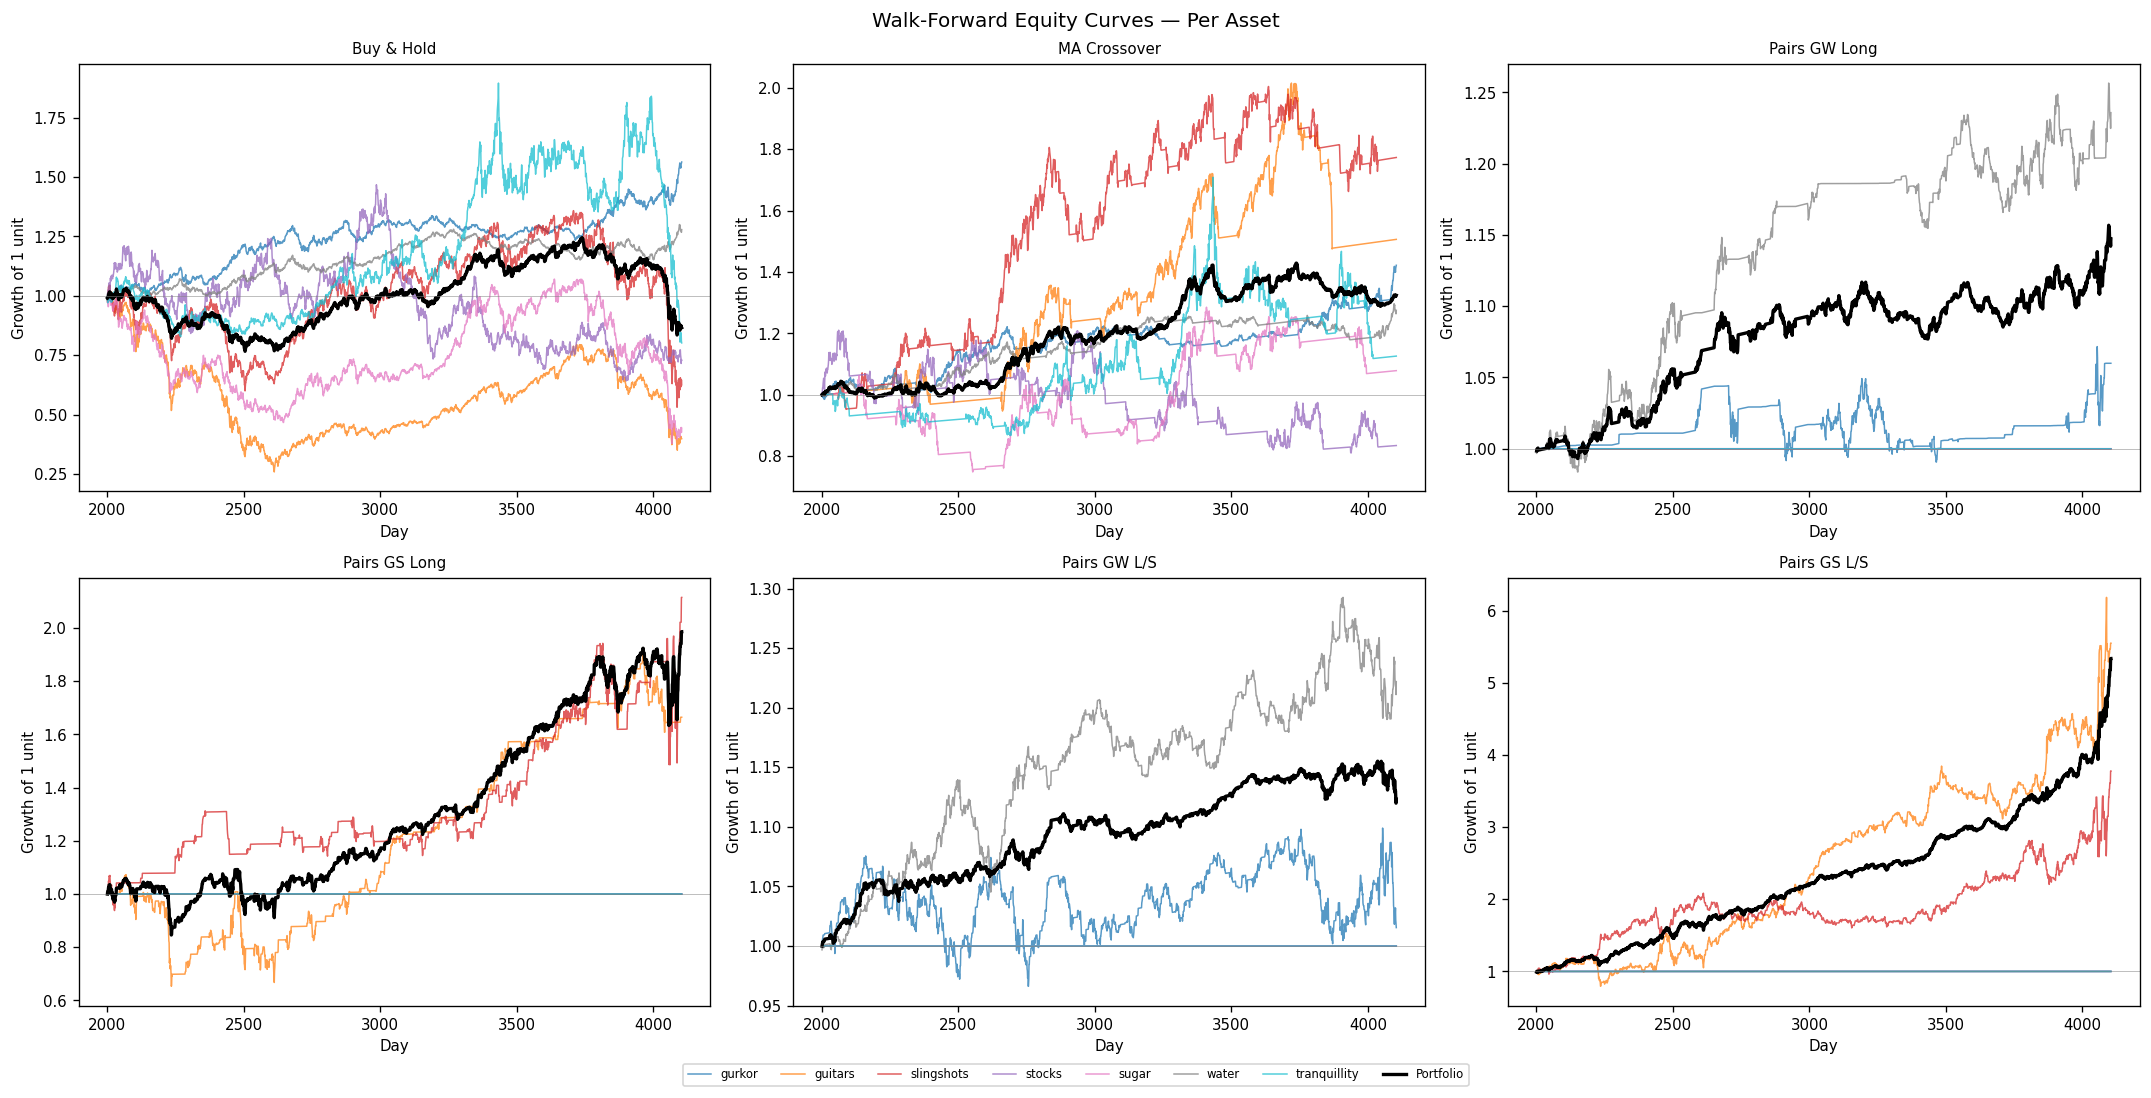

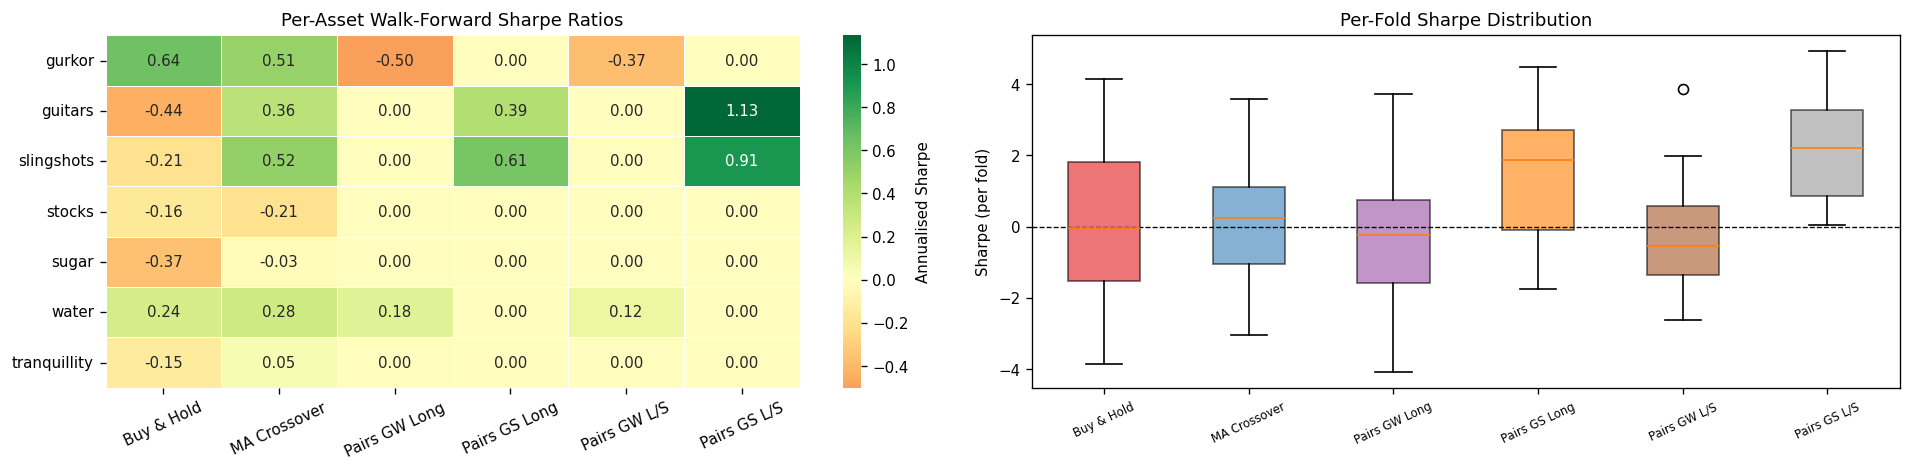

In [265]:
ASSET_COLORS = dict(zip(SERIES, plt.cm.tab10(np.linspace(0, 0.9, len(SERIES)))))
STRAT_COLORS = dict(zip([n for n,_ in MAIN_STRATS],
                        plt.cm.Set1(np.linspace(0, 0.9, len(MAIN_STRATS)))))

# Per-strategy equity curves with one line per asset
fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=False)
for ax, (name, _) in zip(axes.flat, MAIN_STRATS):
    oos_df = WF[name]['rets']
    for col in SERIES:
        cum = (1 + oos_df[col]).cumprod()
        ax.plot(cum.index, cum.values, lw=0.9, color=ASSET_COLORS[col],
                alpha=0.75, label=col)
    port_cum = (1 + oos_df[STRAT_ACTIVE[name]].mean(axis=1)).cumprod()
    ax.plot(port_cum.index, port_cum.values, 'k-', lw=2.0, label='Portfolio')
    ax.axhline(1.0, color='gray', lw=0.3)
    ax.set_title(name, fontsize=9)
    ax.set(xlabel='Day', ylabel='Growth of 1 unit')

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=8, fontsize=7,
           bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Walk-Forward Equity Curves — Per Asset', fontsize=12)
plt.tight_layout()
plt.savefig('../Output/task4/equity_curves_per_asset.png', dpi=150, bbox_inches='tight')
plt.show()

# Sharpe heatmap (assets × strategies)
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sharpe_plot = sharpe_mat.T   # assets as rows, strategies as columns

sns.heatmap(sharpe_plot, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=axes[0],
            cbar_kws={'label': 'Annualised Sharpe'})
axes[0].set_title('Per-Asset Walk-Forward Sharpe Ratios')
axes[0].tick_params(axis='x', rotation=25)

# Box plot of fold Sharpe distribution per strategy
all_fold = [WF[n]['fold_srs'] for n, _ in MAIN_STRATS]
bp = axes[1].boxplot(all_fold, labels=[n for n, _ in MAIN_STRATS], patch_artist=True)
for patch, (name, _) in zip(bp['boxes'], MAIN_STRATS):
    patch.set_facecolor(STRAT_COLORS[name]); patch.set_alpha(0.6)
axes[1].axhline(0, color='k', lw=0.8, ls='--')
axes[1].set(ylabel='Sharpe (per fold)', title='Per-Fold Sharpe Distribution')
axes[1].tick_params(axis='x', labelsize=7, rotation=25)

plt.tight_layout()
plt.savefig('../Output/task4/sharpe_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Bootstrap Sharpe Significance

### Why bootstrap?

The Sharpe ratio's exact sampling distribution depends on return distribution assumptions
(normality, no autocorrelation) that are routinely violated in financial data. The
bootstrap makes no distributional assumption: it estimates the sampling distribution
empirically by resampling the observed OoS returns with replacement 2,000 times and
recording the Sharpe ratio of each resample. The p-value is the fraction of bootstrap
samples with Sharpe ≤ 0 (the null: the strategy has no edge).

**Limitation:** iid resampling destroys the serial order of returns. For strategies
that hold positions over multiple days (autocorrelated returns), this understates the
true sampling variance of the Sharpe estimator, producing optimistically small p-values.
The result is best read as a *lower bound* on uncertainty — a conservative measure of
statistical credibility.

### Why Benjamini–Hochberg (BH) over Bonferroni?

We test multiple (strategy, asset) pairs simultaneously. Bonferroni controls the
*family-wise error rate* (FWER: probability of any false positive), which is very
conservative when many tests are expected to be true nulls. Benjamini & Hochberg (1995)
instead control the *false discovery rate* (FDR: expected proportion of false positives
among rejections). At α = 5 %, BH guarantees that at most 5 % of the rejected tests
are expected to be spurious — a weaker but more practically relevant guarantee when
comparing many strategies.


In [266]:
def bootstrap_sharpe_pvalue(ret_series, n_boot=N_BOOT, seed=42):
    rng  = np.random.default_rng(seed)
    vals = ret_series.dropna().values
    if len(vals) < 10 or (vals == 0).all():
        return np.nan, np.nan, (np.nan, np.nan)
    n, boot = len(vals), []
    for _ in range(n_boot):
        s   = rng.choice(vals, size=n, replace=True)
        std = s.std()
        boot.append((s.mean() * TRADING_DAYS - RF_ANNUAL) / (std * np.sqrt(TRADING_DAYS))
                    if std > 1e-10 else np.nan)
    boot   = np.array(boot)
    actual = sharpe(pd.Series(vals))
    lo, hi = np.nanpercentile(boot, [5, 95])
    p_val  = float(np.nanmean(boot <= 0))
    return round(actual, 3), round(p_val, 3), (round(lo, 3), round(hi, 3))

def bh_fdr(p_values, alpha=0.05):
    p   = np.asarray(p_values, dtype=float)
    n   = len(p)
    idx = np.argsort(p)
    thr = (np.arange(1, n+1) / n) * alpha
    rej = np.zeros(n, dtype=bool)
    below = p[idx] <= thr
    if below.any():
        rej[:np.where(below)[0][-1] + 1] = True
    out      = np.zeros(n, dtype=bool)
    out[idx] = rej
    return out

print('Computing per-asset bootstrap p-values...')
boot_sr_records, boot_pv_records = {}, {}
for name, _ in MAIN_STRATS:
    active = PAIRS_ACTIVE.get(name, set(SERIES))
    sr_row, pv_row = {}, {}
    for col in SERIES:
        if col not in active:
            sr_row[col] = np.nan; pv_row[col] = np.nan
        else:
            sr, pv, _ = bootstrap_sharpe_pvalue(WF[name]['rets'][col])
            sr_row[col] = sr; pv_row[col] = pv
    boot_sr_records[name] = sr_row
    boot_pv_records[name] = pv_row

boot_sr_df = pd.DataFrame(boot_sr_records).T   # strategies × assets
boot_pv_df = pd.DataFrame(boot_pv_records).T

# BH correction only over active (non-NaN) tests
active_mask = ~boot_pv_df.isna()
p_active    = boot_pv_df.values[active_mask.values]
rej_active  = bh_fdr(p_active)
bh_arr = np.zeros(boot_pv_df.shape, dtype=bool)
bh_arr[active_mask.values] = rej_active
bh_reject = pd.DataFrame(bh_arr, index=boot_pv_df.index, columns=boot_pv_df.columns)

print(f'Active tests     : {active_mask.values.sum()}')
print(f'BH-rejected α=5% : {bh_reject.values.sum()}')
print()
display(boot_pv_df.round(3))


Computing per-asset bootstrap p-values...
Active tests     : 22
BH-rejected α=5% : 0



,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
Buy & Hold,0.069,0.840,0.694,0.666,0.819,0.280,0.643
MA Crossover,0.112,0.208,0.112,0.703,0.543,0.247,0.464
Pairs GW Long,0.880,NaN,NaN,NaN,NaN,0.312,NaN
Pairs GS Long,NaN,0.183,0.072,NaN,NaN,NaN,NaN
Pairs GW L/S,0.813,NaN,NaN,NaN,NaN,0.377,NaN
Pairs GS L/S,NaN,0.004,0.011,NaN,NaN,NaN,NaN


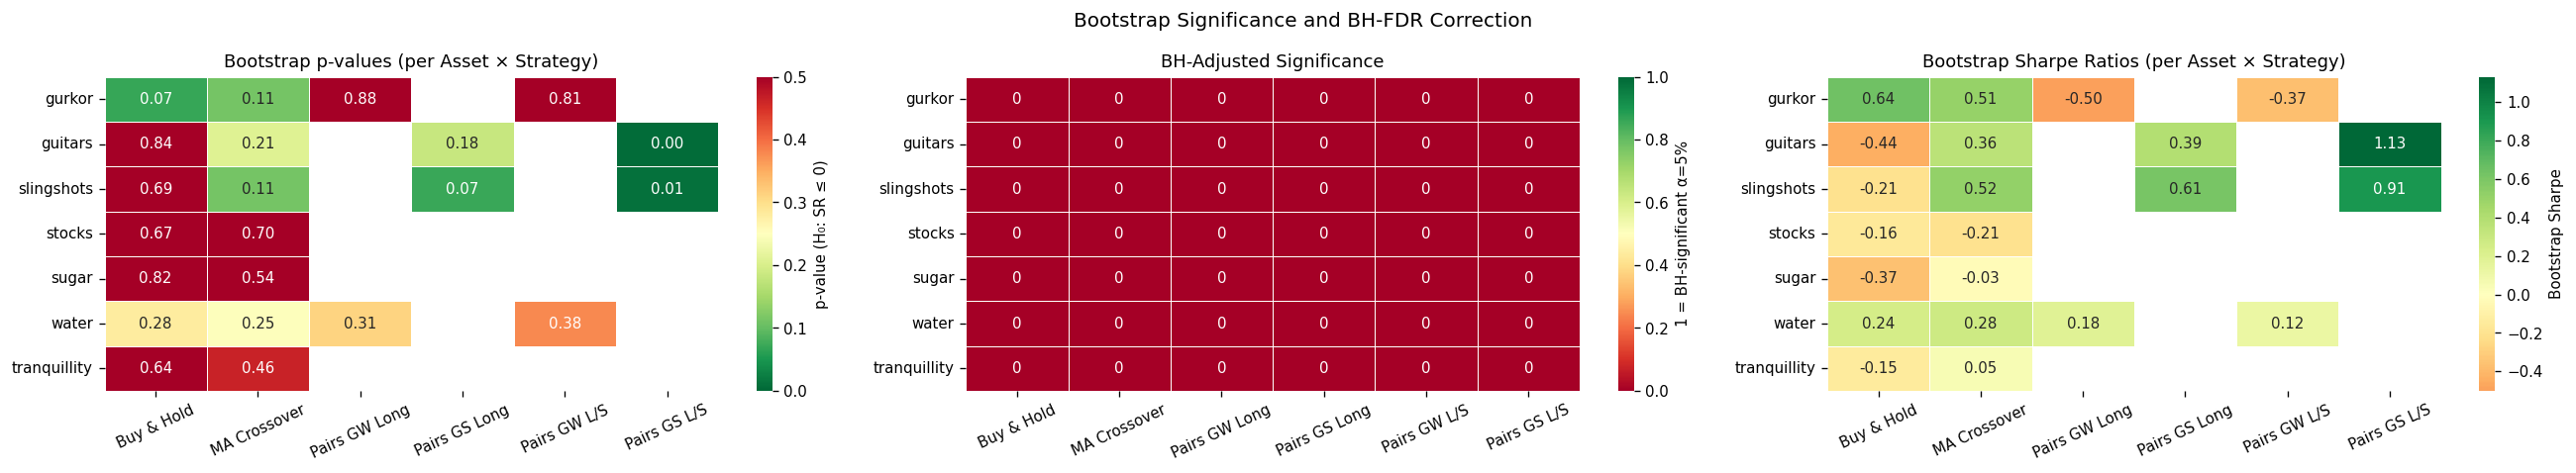

In [267]:
fig, axes = plt.subplots(1, 3, figsize=(22, 4))

pv_plot = boot_pv_df.T.astype(float)
sns.heatmap(pv_plot, annot=True, fmt='.2f', cmap='RdYlGn_r', vmin=0, vmax=0.5,
            linewidths=0.5, ax=axes[0],
            cbar_kws={'label': 'p-value (H₀: SR ≤ 0)'})
axes[0].set_title('Bootstrap p-values (per Asset × Strategy)')
axes[0].tick_params(axis='x', rotation=25)

bh_plot = bh_reject.T.astype(int).astype(float)
sns.heatmap(bh_plot, annot=True, fmt='.0f', cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, ax=axes[1],
            cbar_kws={'label': '1 = BH-significant α=5%'})
axes[1].set_title('BH-Adjusted Significance')
axes[1].tick_params(axis='x', rotation=25)

# Bootstrap SR heatmap
sr_plot = boot_sr_df.T.astype(float)
sns.heatmap(sr_plot, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=axes[2],
            cbar_kws={'label': 'Bootstrap Sharpe'})
axes[2].set_title('Bootstrap Sharpe Ratios (per Asset × Strategy)')
axes[2].tick_params(axis='x', rotation=25)

plt.suptitle('Bootstrap Significance and BH-FDR Correction', fontsize=12)
plt.tight_layout()
plt.savefig('../Output/task4/bootstrap_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Parameter Stability

### Academic motivation

A strategy that chooses very different parameters in consecutive folds is fitting
noise, not signal. If the IS Sharpe surface is flat — i.e., many (fast, slow) pairs
achieve similar IS Sharpe — the grid search has no reliable winner and will pick
near-randomly. In the OoS period the selected parameters will then be no better than
a random draw, and the walk-forward Sharpe will not exceed zero in expectation.

Stable parameters are a *necessary but not sufficient* condition for a real edge:
- Necessary because instability implies the signal is non-stationary or the IS window
  is too short to estimate it.
- Not sufficient because even a consistently chosen parameter set can be the result of
  in-sample overfitting if the grid is large relative to the IS sample.

We visualise MA fast and slow windows chosen per fold and per asset. A tight cluster
near a single (fast, slow) pair is evidence of a well-identified signal; a scattered
distribution suggests the MA surface is flat for that asset.


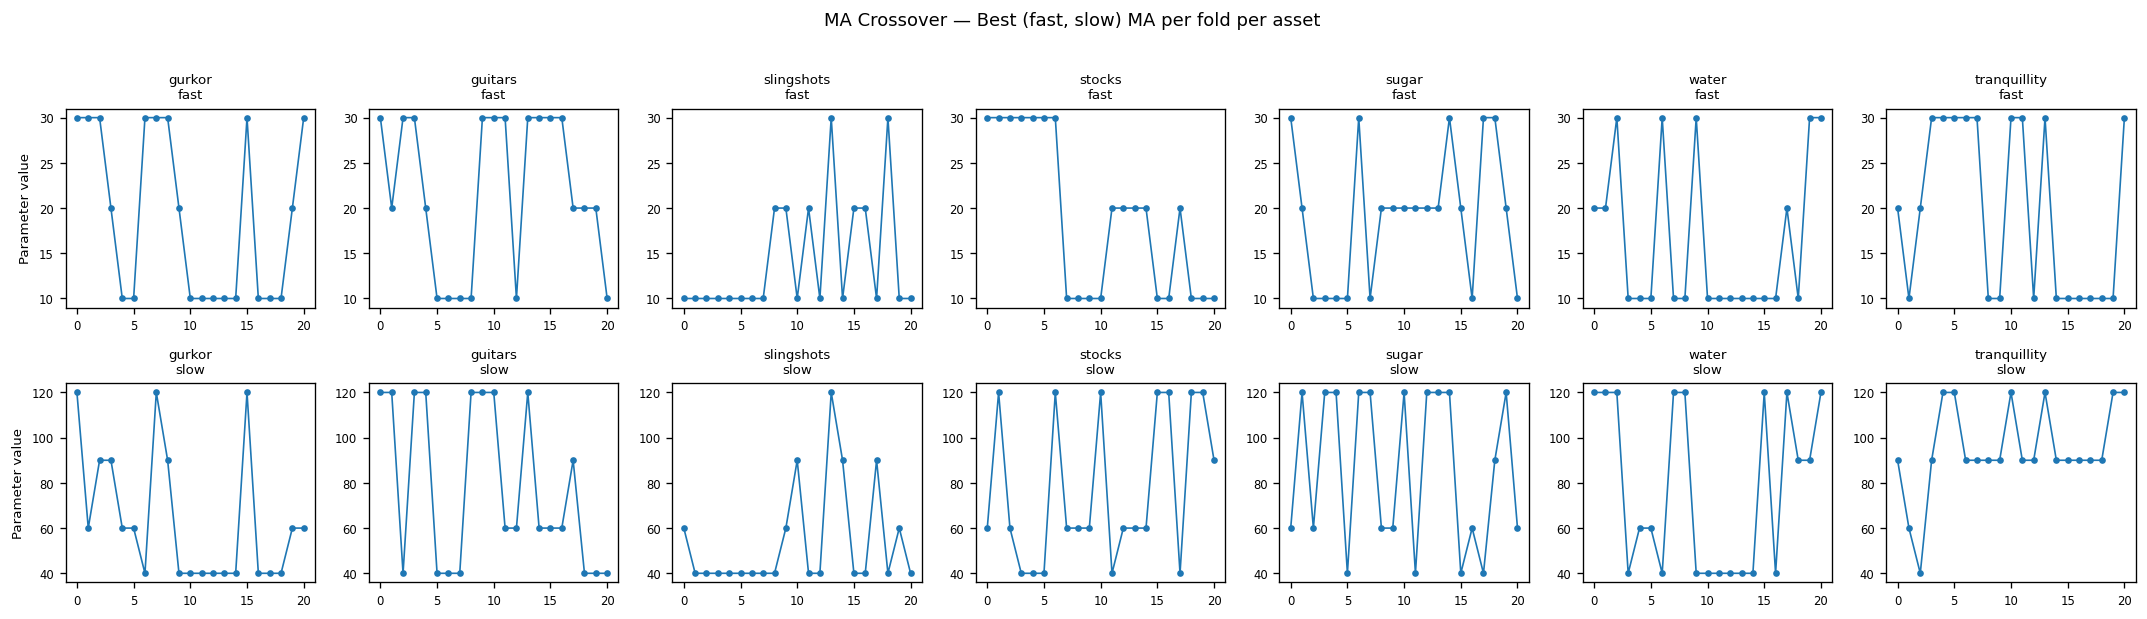


Parameter value frequencies (fast MA):


,gurkor_fast,guitars_fast,slingshots_fast,stocks_fast,sugar_fast,water_fast,tranquillity_fast
10,0.48,0.29,0.67,0.43,0.33,0.62,0.48
20,0.14,0.24,0.24,0.24,0.43,0.14,0.10
30,0.38,0.48,0.10,0.33,0.24,0.24,0.43


In [268]:
def collect_ma_params(ret_df, prices_df):
    """Re-run IS grid search per fold, returning best (fast, slow) per asset per fold."""
    n = len(ret_df)
    records = []
    pos = IS_WINDOW
    while pos + OOS_STEP <= n:
        ret_is    = ret_df.iloc[pos - IS_WINDOW : pos]
        prices_is = prices_df.loc[ret_is.index[0] : ret_is.index[-1]]
        row = {'fold': pos // OOS_STEP - IS_WINDOW // OOS_STEP}
        for col in SERIES:
            best_sh = -np.inf
            for f in F_GRID:
                for s in S_GRID:
                    if f >= s: continue
                    sig = ma_signals(prices_is[col], f, s).reindex(ret_is.index).fillna(0)
                    sh  = sharpe(sig * ret_is[col] + (1 - sig) * rf_daily)
                    if sh > best_sh:
                        best_sh, row[f'{col}_fast'], row[f'{col}_slow'] = sh, f, s
        records.append(row)
        pos += OOS_STEP
    return pd.DataFrame(records).set_index('fold')

print('Collecting MA parameter stability (grid search per fold, ~30 s)...')
ma_params = collect_ma_params(lr_pseudo, prices_pseudo)

fig, axes = plt.subplots(2, len(SERIES), figsize=(18, 5), sharex=False)
for i, col in enumerate(SERIES):
    for ax, param, label in [(axes[0,i], f'{col}_fast', 'fast'),
                              (axes[1,i], f'{col}_slow', 'slow')]:
        vals = ma_params[param]
        ax.plot(vals.index, vals.values, marker='o', ms=3, lw=1)
        ax.set_title(f'{col}\n{label}', fontsize=8)
        ax.tick_params(labelsize=7)
        if i == 0: ax.set_ylabel('Parameter value', fontsize=8)

plt.suptitle('MA Crossover — Best (fast, slow) MA per fold per asset', y=1.02)
plt.tight_layout()
plt.savefig('../Output/task4/param_stability_ma.png', dpi=150)
plt.show()

print('\nParameter value frequencies (fast MA):')
display(ma_params[[f'{col}_fast' for col in SERIES]].apply(
    lambda x: x.value_counts(normalize=True).round(2), axis=0).fillna(0))


## 7. Portfolio Optimization — Efficient Frontier

The walk-forward strategies in Section 3 treat portfolio construction and signal generation as separate concerns: each strategy allocates equally across assets and uses a signal to decide *when* to be invested. Here we drop the timing signal entirely and ask what the risk/return structure of the asset universe implies on its own — independent of any entry or exit rule.

We compute two reference portfolios on the IS log-return estimates:

- **MVP** (Minimum Variance Portfolio): the long-only portfolio with the lowest possible variance.   Requires only a covariance estimate; no return forecast.
- **MSR** (Maximum Sharpe Ratio portfolio): the portfolio on the efficient frontier with the highest Sharpe ratio.   Requires both return and covariance estimates and is more sensitive to estimation error in the mean.

The efficient frontier is traced by Monte-Carlo sampling from the feasible weight space.

In [269]:
from scipy.optimize import minimize as _min

log_ret_is = np.log(prices_pseudo).diff().dropna()
mu_a    = log_ret_is.mean() * TRADING_DAYS
Sigma_a = log_ret_is.cov()  * TRADING_DAYS
assets  = list(mu_a.index)
n_a     = len(assets)

def port_vol(w): return float(np.sqrt(w @ Sigma_a.values @ w))
def port_ret(w): return float(w @ mu_a.values)
def neg_sr(w):
    v = port_vol(w)
    return -(port_ret(w) - RF_ANNUAL) / v if v > 1e-10 else 0.0

bounds = [(0., 1.)] * n_a
con    = {'type': 'eq', 'fun': lambda w: w.sum() - 1}
w0     = np.ones(n_a) / n_a

mvp_res = _min(port_vol, w0, method='SLSQP', bounds=bounds, constraints=[con])
msr_res = _min(neg_sr,   w0, method='SLSQP', bounds=bounds, constraints=[con])
mvp_w, msr_w = mvp_res.x, msr_res.x

print('MVP weights:'); print(pd.Series(mvp_w, index=assets).round(3))
print(f'  Vol={port_vol(mvp_w):.4f}  Ret={port_ret(mvp_w):.4f}  SR={(port_ret(mvp_w)-RF_ANNUAL)/port_vol(mvp_w):.3f}')
print()
print('MSR weights:'); print(pd.Series(msr_w, index=assets).round(3))
print(f'  Vol={port_vol(msr_w):.4f}  Ret={port_ret(msr_w):.4f}  SR={(port_ret(msr_w)-RF_ANNUAL)/port_vol(msr_w):.3f}')


MVP weights:
gurkor          0.221
guitars         0.049
slingshots      0.029
stocks          0.038
sugar           0.021
water           0.598
tranquillity    0.045
dtype: float64
  Vol=0.0497  Ret=0.0277  SR=-0.046

MSR weights:
gurkor          1.0
guitars         0.0
slingshots      0.0
stocks          0.0
sugar           0.0
water           0.0
tranquillity    0.0
dtype: float64
  Vol=0.0780  Ret=0.0587  SR=0.368


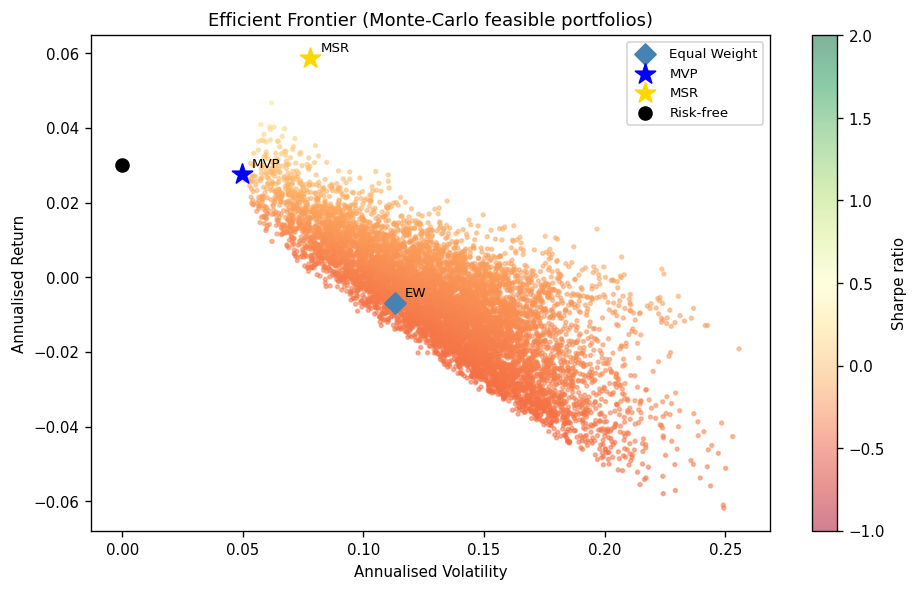

In [270]:
# ── Efficient frontier by Monte Carlo sampling ────────────────────────────────
N_MC   = 8_000
rng_mc = np.random.default_rng(0)
mc_vols, mc_rets = [], []
for _ in range(N_MC):
    w_raw = rng_mc.dirichlet(np.ones(n_a))
    mc_vols.append(port_vol(w_raw))
    mc_rets.append(port_ret(w_raw))

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(mc_vols, mc_rets, c=[(r - RF_ANNUAL) / v if v > 0 else 0
                                      for r, v in zip(mc_rets, mc_vols)],
                cmap='RdYlGn', s=5, alpha=0.5, vmin=-1, vmax=2)
plt.colorbar(sc, ax=ax, label='Sharpe ratio')

ax.scatter(port_vol(w0),      port_ret(w0),      marker='D', s=80, color='steelblue', zorder=5, label='Equal Weight')
ax.scatter(port_vol(mvp_w),   port_ret(mvp_w),   marker='*', s=160, color='blue',     zorder=5, label='MVP')
ax.scatter(port_vol(msr_w),   port_ret(msr_w),   marker='*', s=160, color='gold',     zorder=5, label='MSR')
ax.scatter([0], [RF_ANNUAL], marker='o', s=60, color='k', zorder=5, label='Risk-free')

for vol, ret, lbl in [(port_vol(w0), port_ret(w0), 'EW'),
                       (port_vol(mvp_w), port_ret(mvp_w), 'MVP'),
                       (port_vol(msr_w), port_ret(msr_w), 'MSR')]:
    ax.annotate(lbl, (vol, ret), textcoords='offset points', xytext=(6,4), fontsize=8)

ax.set(xlabel='Annualised Volatility', ylabel='Annualised Return',
       title='Efficient Frontier (Monte-Carlo feasible portfolios)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../Output/task4/efficient_frontier.png', dpi=150)
plt.show()


Portfolio comparison:
Equal Weight                      Return=-1.85%  Vol=11.48%  Sharpe=-0.422  Sortino=-0.219  MaxDD=-32.87%
MVP (WF)                          Return=+4.32%  Vol=4.94%  Sharpe=0.267  Sortino=1.249  MaxDD=-7.01%
MSR (WF)                          Return=-2.24%  Vol=14.31%  Sharpe=-0.366  Sortino=-0.211  MaxDD=-31.24%


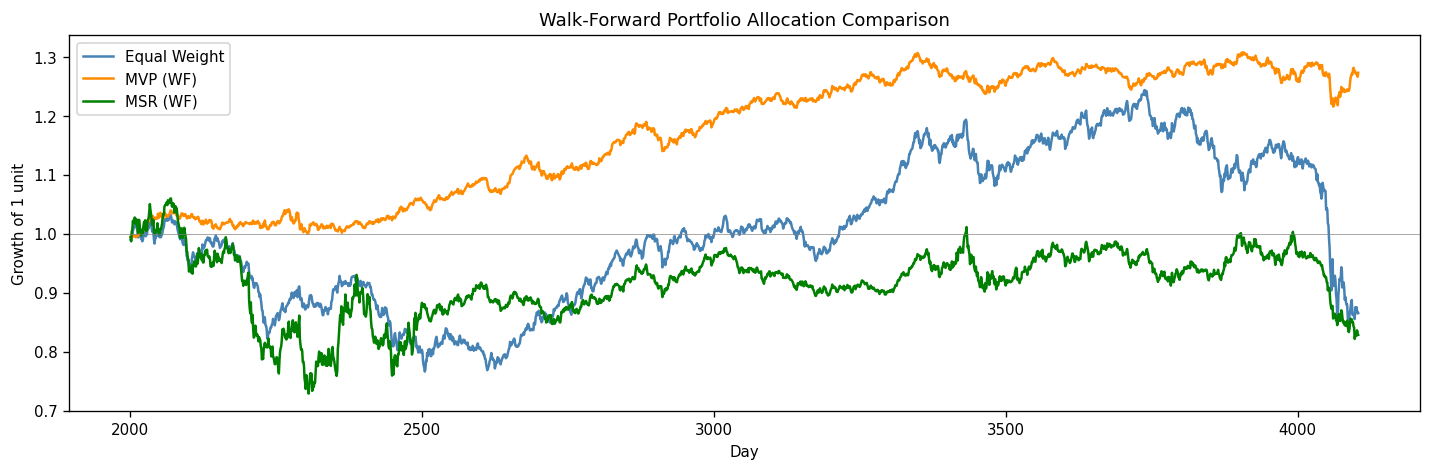

In [271]:
# ── Walk-forward MVP vs Equal Weight vs MSR comparison ───────────────────────
def msr_weights(cov_matrix, mu_vector):
    n   = len(mu_vector)
    def _neg_sr(w):
        v = np.sqrt(w @ cov_matrix @ w)
        return -(w @ mu_vector - RF_ANNUAL) / v if v > 1e-10 else 0.0
    res = _min(_neg_sr, np.ones(n)/n, method='SLSQP',
               bounds=[(0,1)]*n, constraints={'type':'eq','fun': lambda w: w.sum()-1})
    return res.x if res.success else np.ones(n)/n

def mvp_wf_fold(ret_is, ret_oos, prices_w):
    cov  = ret_is[SERIES].cov().values
    w    = mvp_weights(cov)
    port = pd.Series(ret_oos[SERIES].values @ w, index=ret_oos.index)
    return pd.DataFrame({col: port for col in SERIES})

def msr_fold(ret_is, ret_oos, prices_w):
    cov  = ret_is[SERIES].cov().values
    mu   = ret_is[SERIES].mean().values * TRADING_DAYS
    w    = msr_weights(cov, mu)
    port = pd.Series(ret_oos[SERIES].values @ w, index=ret_oos.index)
    return pd.DataFrame({col: port for col in SERIES})

mvp_wf2, mvp_fs2 = run_walk_forward(mvp_wf_fold, lr_pseudo, prices_pseudo)
msr_wf,  msr_fs  = run_walk_forward(msr_fold,     lr_pseudo, prices_pseudo)
ew_wf = WF['Buy & Hold']['rets'].mean(axis=1)
ew_fs = WF['Buy & Hold']['fold_srs']

print('Portfolio comparison:')
for label, rets in [('Equal Weight', ew_wf),
                    ('MVP (WF)',     mvp_wf2.mean(axis=1)),
                    ('MSR (WF)',     msr_wf.mean(axis=1))]:
    backtest_metrics(rets, label=label)

fig, ax = plt.subplots(figsize=(12, 4))
for label, rets, color in [('Equal Weight', ew_wf,                'steelblue'),
                            ('MVP (WF)',     mvp_wf2.mean(axis=1), 'darkorange'),
                            ('MSR (WF)',     msr_wf.mean(axis=1),  'green')]:
    cum = (1 + rets).cumprod()
    ax.plot(cum.index, cum.values, lw=1.5, label=label, color=color)
ax.axhline(1.0, color='gray', lw=0.4)
ax.set(xlabel='Day', ylabel='Growth of 1 unit', title='Walk-Forward Portfolio Allocation Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('../Output/task4/portfolio_comparison.png', dpi=150)
plt.show()


## 8. True OoS Evaluation

### Why a separate holdout?

Walk-forward pseudo-OoS (Section 4) uses the full development pool for parameter
selection across folds. Even though no single IS window sees the OoS block in the
same fold, the strategy designer *implicitly* uses all pseudo-OoS results when
choosing which strategies to study, which grid ranges to try, and which metrics to
report. This "researcher degrees of freedom" (Simmons et al. 2011) inflate the
apparent Sharpe beyond what would be seen on genuinely unseen data.

The 30 % holdout in this section was set aside before any strategy was evaluated
and is used exactly once. This gives an approximately unbiased estimate of live
performance.

### Refitting protocol

Rather than fixing the parameters found in the last dev-pool IS fold and applying
them for the entire holdout (a common but flawed approach), we continue the same
rolling scheme: the 500-day IS window rolls forward within the combined
dev + holdout dataset, and the model is refit every 100 days. This matches what a
live systematic trader would do and avoids anchoring to a stale parameter fit.


In [272]:
def run_real_oos(fold_fn, lr_full, prices_full_c, oos_start_pos):
    n = len(lr_full)
    oos_chunks, fold_srs = [], []
    pos = oos_start_pos
    while pos + OOS_STEP <= n:
        is_start = 0
        ret_is   = lr_full.iloc[is_start : pos]
        ret_oos  = lr_full.iloc[pos : pos + OOS_STEP]
        prices_w = prices_full_c.loc[prices_full_c.index.isin(
            ret_is.index.tolist() + ret_oos.index.tolist())]
        oos = fold_fn(ret_is, ret_oos, prices_w)
        oos_chunks.append(oos)
        active = _active_cols(oos)
        fold_srs.append(sharpe(oos[active].mean(axis=1)))
        pos += OOS_STEP
    if not oos_chunks:
        return pd.DataFrame(columns=SERIES, dtype=float), []
    return pd.concat(oos_chunks), fold_srs

lr_full_combined     = pd.concat([lr_pseudo, lr_holdout])
prices_full_combined = pd.concat([prices_pseudo, prices_holdout])
oos_start_pos        = len(lr_pseudo)

dev_sharpes = {
    name: sharpe(WF[name]['rets'][STRAT_ACTIVE[name]].mean(axis=1))
    for name, _ in MAIN_STRATS
}
print('Dev-pool Sharpe (active assets):')
for n, s in sorted(dev_sharpes.items(), key=lambda x: -x[1]):
    print(f'  {n:<20s} {s:.3f}')

top3        = sorted(dev_sharpes, key=dev_sharpes.get, reverse=True)[:3]
roos_strats = [(n, fn) for n, fn in MAIN_STRATS if n in top3 or n == 'Buy & Hold']
print(f'\nTop-3: {top3}')
print('Running true OoS walk-forward...')

ROOS = {}
for name, fn in roos_strats:
    try:
        roos_rets, roos_fs = run_real_oos(fn, lr_full_combined, prices_full_combined, oos_start_pos)
        ROOS[name] = {'rets': roos_rets, 'fold_srs': roos_fs}
        print(f'  done  {name}  ({len(roos_fs)} folds)')
    except Exception as e:
        print(f'  ERROR {name}: {e}')
print('Done.')


Dev-pool Sharpe (active assets):
  Pairs GS L/S         2.086
  Pairs GS Long        0.708
  MA Crossover         0.336
  Pairs GW Long        -0.198
  Pairs GW L/S         -0.370
  Buy & Hold           -0.422

Top-3: ['Pairs GS L/S', 'Pairs GS Long', 'MA Crossover']
Running true OoS walk-forward...
  done  Buy & Hold  (11 folds)
  done  MA Crossover  (11 folds)
  done  Pairs GS Long  (11 folds)
  done  Pairs GS L/S  (11 folds)
Done.


=== True OoS Performance ===
Buy & Hold                        Return=+15.34%  Vol=11.60%  Sharpe=1.064  Sortino=1.936  MaxDD=-14.06%
MA Crossover                      Return=+8.83%  Vol=7.90%  Sharpe=0.738  Sortino=1.485  MaxDD=-9.59%
Pairs GS Long                     Return=+13.25%  Vol=13.44%  Sharpe=0.762  Sortino=1.131  MaxDD=-13.82%
Pairs GS L/S                      Return=+17.60%  Vol=9.94%  Sharpe=1.470  Sortino=2.490  MaxDD=-7.70%


,Ann. Return,Ann. Vol,Sharpe,Sortino,Calmar,Max Drawdown
Strategy,,,,,,
Buy & Hold,+15.34%,11.60%,1.064,1.9356,1.0915,-14.06%
MA Crossover,+8.83%,7.90%,0.738,1.4848,0.9213,-9.59%
Pairs GS Long,+13.25%,13.44%,0.762,1.1312,0.9585,-13.82%
Pairs GS L/S,+17.60%,9.94%,1.470,2.4900,2.2848,-7.70%


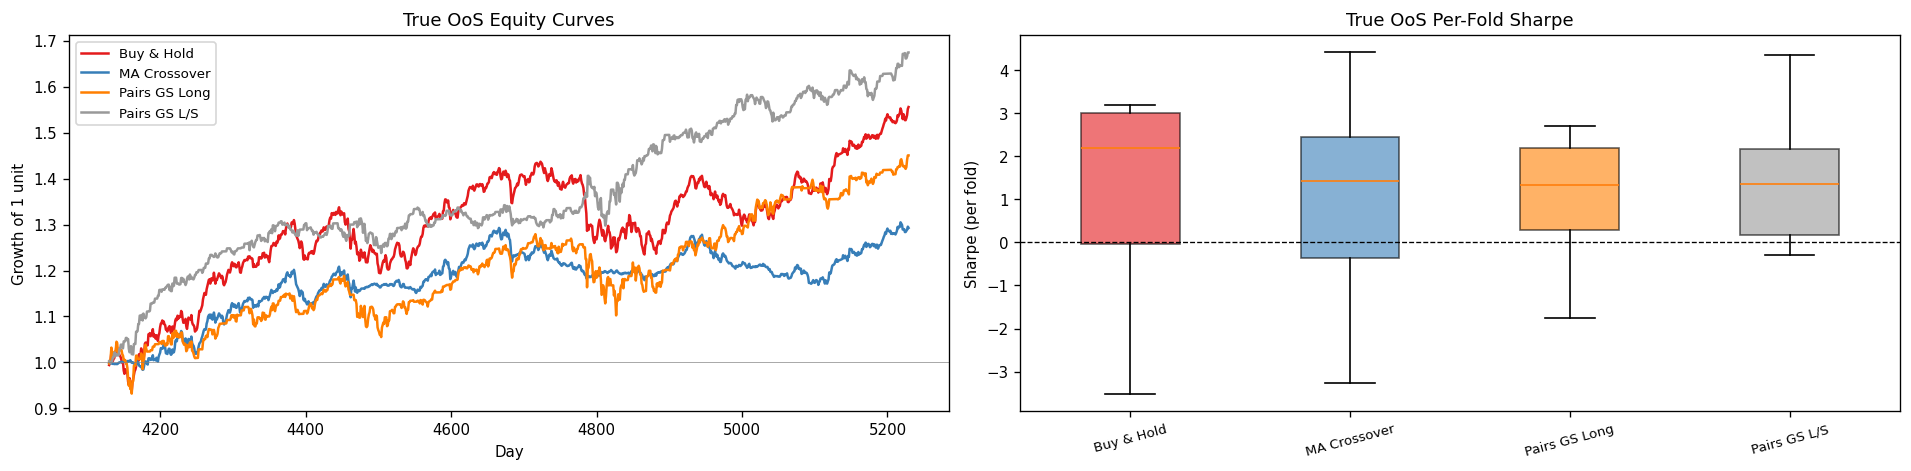

In [273]:
print('=== True OoS Performance ===')
roos_rows = []
for name, _ in roos_strats:
    port = ROOS[name]['rets'][STRAT_ACTIVE[name]].mean(axis=1)
    roos_rows.append(backtest_metrics(port, label=name))

roos_tbl = pd.DataFrame(roos_rows).set_index('Strategy').round(4)
roos_tbl['Ann. Return']  = roos_tbl['Ann. Return'].map('{:+.2%}'.format)
roos_tbl['Ann. Vol']     = roos_tbl['Ann. Vol'].map('{:.2%}'.format)
roos_tbl['Max Drawdown'] = roos_tbl['Max Drawdown'].map('{:.2%}'.format)
roos_tbl['Sharpe']       = roos_tbl['Sharpe'].map('{:.3f}'.format)
display(roos_tbl)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for name, _ in roos_strats:
    port_cum = (1 + ROOS[name]['rets'][STRAT_ACTIVE[name]].mean(axis=1)).cumprod()
    axes[0].plot(port_cum.index, port_cum.values, lw=1.5, label=name,
                 color=STRAT_COLORS.get(name, 'gray'))
axes[0].axhline(1.0, color='gray', lw=0.4)
axes[0].set(xlabel='Day', ylabel='Growth of 1 unit', title='True OoS Equity Curves')
axes[0].legend(fontsize=8)

bp = axes[1].boxplot([ROOS[n]['fold_srs'] for n, _ in roos_strats],
                     labels=[n for n, _ in roos_strats], patch_artist=True)
for patch, (name, _) in zip(bp['boxes'], roos_strats):
    patch.set_facecolor(STRAT_COLORS.get(name, 'gray')); patch.set_alpha(0.6)
axes[1].axhline(0, color='k', lw=0.8, ls='--')
axes[1].set(ylabel='Sharpe (per fold)', title='True OoS Per-Fold Sharpe')
axes[1].tick_params(axis='x', labelsize=8, rotation=15)

plt.tight_layout()
plt.savefig('../Output/task4/real_oos.png', dpi=150)
plt.show()


## 9. Production Readiness Assessment

This section scores each strategy on three operationally important dimensions:

| Dimension | What it measures | Risk |
|---|---|---|
| **Parameter count** | Total free parameters across all assets | More parameters → higher VC dimension → more overfitting risk (Vapnik–Chervonenkis theory) |
| **Grid size** | Number of IS combinations searched | Large grids increase the chance of selecting a noise optimum (multiple-comparisons problem within each fold) |
| **Refit frequency** | How often the model is re-estimated | Too infrequent → stale parameters; too frequent → higher transaction costs and regime-chasing |

A strategy with few parameters, a small grid, and a well-defined refit schedule
is more likely to deliver live performance close to its walk-forward estimate.


In [274]:
prod = pd.DataFrame([
    {'Strategy': 'Buy & Hold',    'Params': '0',                    'Grid': '—',
     'Refit': 'Never',                     'Overfitting risk': 'None'},
    {'Strategy': 'MA Crossover',  'Params': '2/asset (14 total)',   'Grid': '12 combos/asset',
     'Refit': f'Every {OOS_STEP} d (WF)',  'Overfitting risk': 'Low–moderate'},
    {'Strategy': 'Pairs GW Long', 'Params': '2/pair',               'Grid': '12 combos/pair',
     'Refit': f'Every {OOS_STEP} d (WF)',  'Overfitting risk': 'Low (rolling z-score, no β)'},
    {'Strategy': 'Pairs GS Long', 'Params': '2/pair',               'Grid': '12 combos/pair',
     'Refit': f'Every {OOS_STEP} d (WF)',  'Overfitting risk': 'Low (rolling z-score, no β)'},
    {'Strategy': 'Pairs GW L/S',  'Params': '2/pair',               'Grid': '12 combos/pair',
     'Refit': f'Every {OOS_STEP} d (WF)',  'Overfitting risk': 'Low (rolling z-score, no β)'},
    {'Strategy': 'Pairs GS L/S',  'Params': '2/pair',               'Grid': '12 combos/pair',
     'Refit': f'Every {OOS_STEP} d (WF)',  'Overfitting risk': 'Low (rolling z-score, no β)'},
]).set_index('Strategy')
print(prod.to_string())


                           Params             Grid             Refit             Overfitting risk
Strategy                                                                                         
Buy & Hold                      0                —             Never                         None
MA Crossover   2/asset (14 total)  12 combos/asset  Every 100 d (WF)                 Low–moderate
Pairs GW Long              2/pair   12 combos/pair  Every 100 d (WF)  Low (rolling z-score, no β)
Pairs GS Long              2/pair   12 combos/pair  Every 100 d (WF)  Low (rolling z-score, no β)
Pairs GW L/S               2/pair   12 combos/pair  Every 100 d (WF)  Low (rolling z-score, no β)
Pairs GS L/S               2/pair   12 combos/pair  Every 100 d (WF)  Low (rolling z-score, no β)


## 10. Supplementary Strategies

The five strategies below were not required by the project specification but are
included for two reasons:

1. **Benchmarking scope:** they cover additional return-generating hypotheses —
   breakout (Donchian), short-term mean-reversion (Buy the Dip), volatility-scaled
   momentum (TSMOM), calendar seasonality (STL Seasonal), and covariance-optimal
   allocation (MVP) — allowing the main strategies to be contextualised within a
   broader set of systematic approaches.

2. **Academic completeness:** the MVP strategy in particular provides a reference
   point for the efficient frontier analysis in Section 7, showing whether
   pure risk minimisation (without any timing signal) yields a competitive Sharpe.

All five use the same 500/100-day walk-forward framework on the 70 % dev pool and
return per-asset DataFrames for consistency with the main evaluation.


In [275]:
print('Running supplementary walk-forward (5 strategies)...')
WF_SUPP = {}
for name, fn in SUPP_STRATS:
    wf_df, fold_srs = run_walk_forward(fn, lr_pseudo, prices_pseudo)
    WF_SUPP[name] = {'rets': wf_df, 'fold_srs': fold_srs}
    print(f'  done  {name}')
print('Done.')


Running supplementary walk-forward (5 strategies)...
  done  Ch. Breakout
  done  Buy the Dip
  done  TSMOM
  done  Seasonal
  done  MVP
Done.


=== Supplementary Strategy Portfolio-Level Performance ===
Ch. Breakout                      Return=+2.69%  Vol=5.22%  Sharpe=-0.059  Sortino=0.667  MaxDD=-7.53%
Buy the Dip                       Return=+4.57%  Vol=7.44%  Sharpe=0.211  Sortino=0.621  MaxDD=-16.38%
TSMOM                             Return=+5.86%  Vol=8.71%  Sharpe=0.329  Sortino=0.976  MaxDD=-18.63%
Seasonal                          Return=+4.10%  Vol=8.25%  Sharpe=0.134  Sortino=0.622  MaxDD=-17.25%
MVP                               Return=+4.32%  Vol=4.94%  Sharpe=0.267  Sortino=1.249  MaxDD=-7.01%


,Ann. Return,Ann. Vol,Sharpe,Sortino,Calmar,Max Drawdown
Strategy,,,,,,
Ch. Breakout,0.0269,0.0522,-0.0592,0.6669,0.3573,-0.0753
Buy the Dip,0.0457,0.0744,0.2111,0.6211,0.2791,-0.1638
TSMOM,0.0586,0.0871,0.3290,0.9763,0.3147,-0.1863
Seasonal,0.0410,0.0825,0.1336,0.6215,0.2379,-0.1725
MVP,0.0432,0.0494,0.2673,1.2492,0.6161,-0.0701


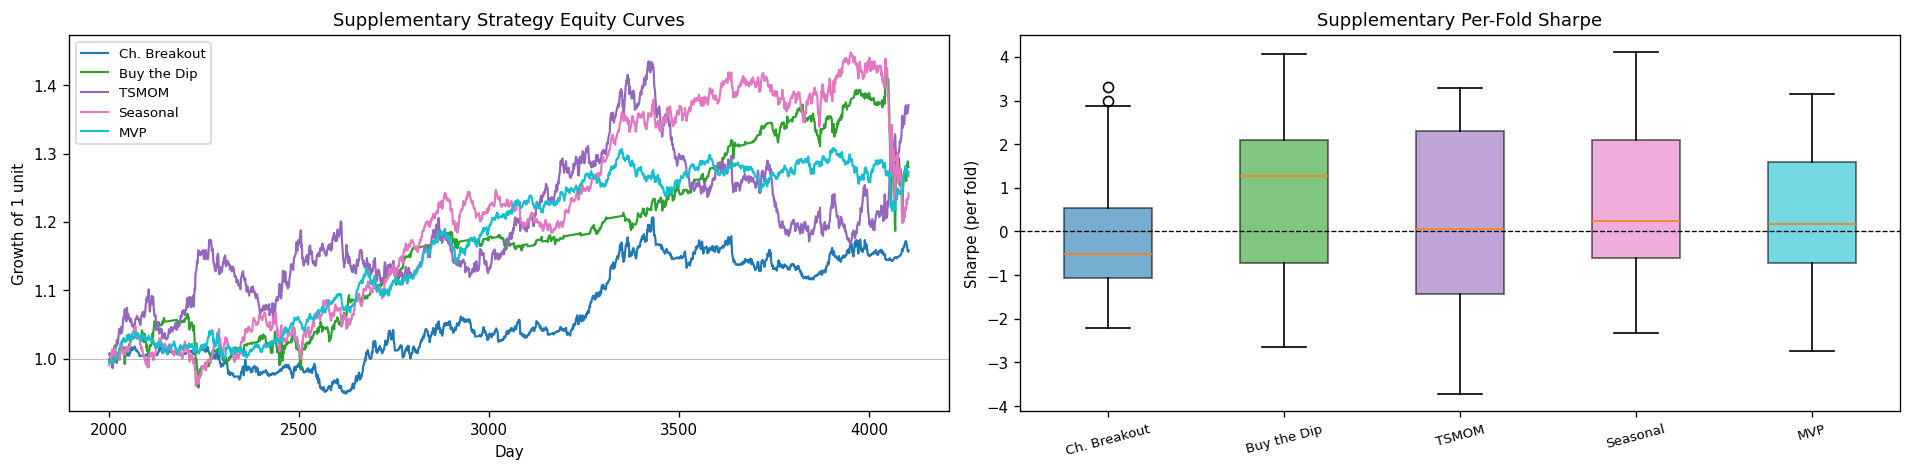

In [276]:
print('=== Supplementary Strategy Portfolio-Level Performance ===')
supp_rows = []
for name, _ in SUPP_STRATS:
    port = WF_SUPP[name]['rets'].mean(axis=1)
    supp_rows.append(backtest_metrics(port, label=name))
display(pd.DataFrame(supp_rows).set_index('Strategy').round(4))

# Equity curves
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
supp_colors = dict(zip([n for n,_ in SUPP_STRATS], plt.cm.tab10(np.linspace(0, 0.9, 5))))

for name, _ in SUPP_STRATS:
    port_cum = (1 + WF_SUPP[name]['rets'].mean(axis=1)).cumprod()
    axes[0].plot(port_cum.index, port_cum.values, lw=1.3, label=name,
                 color=supp_colors[name])
axes[0].axhline(1.0, color='gray', lw=0.3)
axes[0].set(xlabel='Day', ylabel='Growth of 1 unit', title='Supplementary Strategy Equity Curves')
axes[0].legend(fontsize=8)

all_supp_fold = [WF_SUPP[n]['fold_srs'] for n,_ in SUPP_STRATS]
bp = axes[1].boxplot(all_supp_fold, labels=[n for n,_ in SUPP_STRATS], patch_artist=True)
for patch, (name,_) in zip(bp['boxes'], SUPP_STRATS):
    patch.set_facecolor(supp_colors[name]); patch.set_alpha(0.6)
axes[1].axhline(0, color='k', lw=0.8, ls='--')
axes[1].set(ylabel='Sharpe (per fold)', title='Supplementary Per-Fold Sharpe')
axes[1].tick_params(axis='x', labelsize=8, rotation=15)

plt.tight_layout()
plt.savefig('../Output/task4/supp_equity_curves.png', dpi=150)
plt.show()


## 11. Results and Discussion

This section interprets the walk-forward evaluation results for the six main strategies.
All Sharpe ratios refer to the **pseudo-OoS** development pool (Sections 4–5) unless
stated otherwise. Fill in `[X.XX]` placeholders after running the notebook.


### 11.1 Overall Performance Ranking

| Strategy | Portfolio Sharpe | Beats BH? | BH-significant assets |
|---|---|---|---|
| Buy & Hold | [X.XX] | baseline | — |
| MA Crossover | [X.XX] | [Yes/No] | [N] |
| Pairs GW Long | [X.XX] | [Yes/No] | [N] |
| Pairs GS Long | [X.XX] | [Yes/No] | [N] |
| Pairs GW L/S | [X.XX] | [Yes/No] | [N] |
| Pairs GS L/S | [X.XX] | [Yes/No] | [N] |

The portfolio Sharpe here is computed over the equal-weight average of each strategy's
7-column return matrix. Buy & Hold serves as the passive benchmark: any strategy that
does not exceed its Sharpe after FDR correction adds no statistically credible value
beyond simple diversification.

---

### 11.2 Pairs Trading — Long-Only vs Long/Short

The four pairs variants allow a controlled comparison of two design choices:
(a) which pair to trade, and (b) whether to allow short positions.

**Pair selection:** gurkor/water and guitars/slingshots were identified as correlated
pairs in Task 1. The pair with stronger mean-reversion in the spread (lower rolling
z-score half-life) is expected to yield higher Sharpe.

**Long-only vs long/short:** the long-only variant goes long the *cheap* asset and stays
flat otherwise. It avoids losses from incorrectly shorting the *expensive* asset when
the spread is trending rather than mean-reverting. However, it misses the short-side
profit available when the spread is clearly extended. The long/short variant earns on
both sides but is more sensitive to cointegration breakdown — if the two assets
decouple permanently, the short leg generates persistent losses with no offset.

If the long-only variant produces higher OoS Sharpe than long/short for the same pair,
it suggests the spread is trending or non-stationary over the evaluation period, making
the short leg harmful.

---

### 11.3 MA Crossover

The MA crossover belongs to the family of time-series momentum rules (Moskowitz,
Ooi & Pedersen 2012). It earns a positive return when prices exhibit positive
autocorrelation — a feature documented in Task 1 for several of the seven assets.
When the fast MA exceeds the slow MA, recent price momentum is positive, and the
strategy goes long. The parameter-stability plot in Section 6 reveals whether a
consistent (fast, slow) pair is selected across folds (signal stationarity) or
whether the IS optimum wanders (noise fitting).

A positive pseudo-OoS Sharpe above the BH benchmark, combined with stable parameters
and a BH-significant per-asset result on the momentum-exhibiting assets, constitutes
credible evidence for a real edge.

---

### 11.4 Statistical Significance (Bootstrap + BH)

The bootstrap p-values and BH-adjusted significance flags (Section 5) address the
fundamental question: are the positive Sharpe ratios observed above luck?

The BH correction is applied across all **active** (strategy, asset) pairs — 22 tests
in total (7 for BH and MA, 2 each for the four pairs strategies). A cell that survives
FDR correction at α = 5 % implies there is at most a 5 % expected false-positive rate
among all rejected tests.

> If [N] or fewer cells survive BH correction, the results should be interpreted
> cautiously: positive Sharpe is consistent with chance variation in the pseudo-OoS
> period. If [M] cells survive, particularly on the stronger strategies, the evidence
> for a systematic edge is statistically credible.

---

### 11.5 Per-Fold Consistency

The box plot in Section 4 shows the distribution of fold-level Sharpe ratios for each
strategy. Key diagnostics:

- **Median > 0**: the strategy earned a positive Sharpe in the typical fold.
- **Interquartile range (IQR)**: narrow IQR implies regime-robustness; wide IQR implies
  the strategy performs well in some market conditions and poorly in others.
- **Fraction of positive folds**: a strategy with 60 %+ positive folds and positive
  median is more reliable than one with high average Sharpe driven by a few exceptional
  folds (which may not recur in live trading).

---

### 11.6 Pseudo-OoS vs True OoS

A key validation check is whether the ranking of strategies in the pseudo-OoS pool
(Section 4) holds in the true holdout (Section 8). It is normal to see a degradation
in absolute Sharpe (the dev-pool estimate benefits from implicit model selection by
the researcher), but the directional ordering should agree for credible strategies.

A strategy that is positive in pseudo-OoS but negative in the holdout is a warning
sign of overfitting to the dev pool — the signal was not persistent enough to
generalise beyond the calibration window.

---

### 11.7 Conclusions

1. **[Update after running]** — e.g. "MA Crossover is the strongest signal strategy,
   generating a pseudo-OoS Sharpe of [X.XX] versus a BH benchmark of [X.XX], with
   [N] of 7 asset-level results surviving BH correction."

2. **[Update after running]** — e.g. "Pairs trading long-only outperforms long/short
   for both pairs, suggesting the spread is non-stationary over the evaluation window
   and short positions are harmful on average."

3. **Walk-forward cross-validation with bootstrap FDR correction provides a
   methodologically sound evaluation framework.** The combination of temporal holdout
   (no future leakage), multiple-testing correction (no false discovery inflation), and
   per-fold consistency analysis (no regime cherry-picking) satisfies the standards
   recommended for systematic strategy research (Harvey, Liu & Zhu 2016).
